<a href="https://colab.research.google.com/github/Ladyjinxxx/codveda-machine-learning-internship/blob/main/Level_1_Task2_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 1. IMPORT LIBRARIES
#
# This cell imports all the Python libraries required for data manipulation,
# visualization, machine learning, and model evaluation.
#
# These libraries will be used throughout the entire notebook.
# ==============================================================================

# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical computations
import numpy as np

# Import matplotlib for creating graphs and visualizations
import matplotlib.pyplot as plt

# Import seaborn for more attractive statistical visualizations
import seaborn as sns

# Import pathlib for easier file and folder management
from pathlib import Path

# Import Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Import function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import evaluation metrics for regression models
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Set a clean plotting style
plt.style.use("ggplot")

# Set default figure size for all plots
plt.rcParams["figure.figsize"] = (10,6)

# Display confirmation message
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ==============================================================================
# CELL 2. MOUNT GOOGLE DRIVE
#
# This cell mounts Google Drive so that the notebook can directly access
# the dataset and automatically save all outputs.
# ==============================================================================

# Import Google Drive utility
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Display confirmation message
print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# ==============================================================================
# CELL 3. DEFINE FILE PATHS
#
# This cell defines where the dataset is located and creates folders
# where all charts, tables, and prediction results will be saved.
# ==============================================================================

# Define the location of your Google Drive folder
DATA_DIR = Path("/content/drive/MyDrive/LinearRegressionLab")

# Specify the dataset filename
FILE_PATH = DATA_DIR / "4) house Prediction Data Set.csv"

# Create an output folder
OUTPUT_DIR = DATA_DIR / "LinearRegression_Output"

# Create subfolders for better organization
CHARTS_DIR = OUTPUT_DIR / "Charts"
TABLES_DIR = OUTPUT_DIR / "Tables"

# Create the folders if they do not already exist
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Display confirmation
print("Directories are ready.")

Directories are ready.


In [ ]:
# ==============================================================================
# CELL 4. LOAD THE RAW DATASET
#
# The provided dataset contains all values merged into a single column.
# This cell loads the raw file exactly as provided before cleaning.
# ==============================================================================

# Read the raw dataset
raw_df = pd.read_csv(FILE_PATH)

# Display the first five rows
print("First five rows of the raw dataset:")
display(raw_df.head())

# Display the shape of the raw dataset
print(f"\nRaw Dataset Shape: {raw_df.shape}")

First five rows of the raw dataset:


,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...



Raw Dataset Shape: (505, 1)


In [ ]:
# ==============================================================================
# CELL 5. DATA CLEANING
#
# The dataset stores all observations inside a single column separated
# by spaces. This cell separates each value into its own column,
# assigns meaningful feature names, and converts all values to numeric.
# ==============================================================================

# Extract the single column containing all values
single_column = raw_df.iloc[:,0]

# Split every row using whitespace as the separator
split_data = single_column.str.split(expand=True)

# Assign official Boston Housing column names
split_data.columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV"
]

# Convert every column into numeric values
df = split_data.apply(pd.to_numeric)

# Display the cleaned dataset
print("Cleaned Dataset")
display(df.head())

# Display dataset dimensions
print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Save the cleaned dataset
df.to_csv(TABLES_DIR / "Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned Dataset


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7



Rows: 505
Columns: 14
Cleaned dataset saved successfully.


In [ ]:
# ==============================================================================
# CELL 6. DATASET INFORMATION
#
# This cell examines the structure, data types, descriptive statistics,
# and missing values of the cleaned dataset.
# ==============================================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

# Display information about the dataset
df.info()

print("\n")

# Display descriptive statistics
display(df.describe())

print("\nMissing Values\n")

# Count missing values
display(df.isnull().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB




,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000



Missing Values



,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
# ==============================================================================
# CELL 7. CHECK FOR DUPLICATE RECORDS
#
# Duplicate records can affect the performance of a machine learning model.
# This cell identifies duplicate observations and removes them if any exist.
# ==============================================================================

# Count duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate Rows Found: {duplicates}")

# Remove duplicates if present
df = df.drop_duplicates()

print(f"Dataset Shape after Removing Duplicates: {df.shape}")

Duplicate Rows Found: 0
Dataset Shape after Removing Duplicates: (505, 14)


In [ ]:
# ==============================================================================
# CELL 8. CORRELATION ANALYSIS
#
# This cell computes the Pearson correlation coefficients between all variables.
# Correlation values range from -1 to 1:
#
#   +1 : Perfect positive relationship
#    0 : No relationship
#   -1 : Perfect negative relationship
#
# The correlation matrix helps identify which feature has the strongest
# relationship with the target variable (MEDV).
# ==============================================================================

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
display(correlation_matrix)

# Save the correlation matrix
correlation_matrix.to_csv(TABLES_DIR / "Correlation_Matrix.csv")

print("Correlation matrix saved successfully.")

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200283,0.406251,-0.056132,0.420934,-0.218978,0.352701,-0.379627,0.625396,0.582568,0.289394,-0.384839,0.455329,-0.388249
ZN,-0.200283,1.000000,-0.534022,-0.042550,-0.516574,0.311835,-0.569524,0.664395,-0.311717,-0.314351,-0.391713,0.175319,-0.412894,0.360393
INDUS,0.406251,-0.534022,1.000000,0.062350,0.764556,-0.391330,0.645543,-0.708848,0.594167,0.720561,0.380955,-0.356506,0.602737,-0.484126
CHAS,-0.056132,-0.042550,0.062350,1.000000,0.091134,0.091497,0.086461,-0.099109,-0.007907,-0.035965,-0.122570,0.049040,-0.054576,0.175364
NOX,0.420934,-0.516574,0.764556,0.091134,1.000000,-0.302127,0.731461,-0.769221,0.611758,0.668141,0.188918,-0.380006,0.591262,-0.427295
RM,-0.218978,0.311835,-0.391330,0.091497,-0.302127,1.000000,-0.240211,0.205170,-0.209277,-0.291680,-0.355116,0.127754,-0.613734,0.695365
AGE,0.352701,-0.569524,0.645543,0.086461,0.731461,-0.240211,1.000000,-0.747872,0.456232,0.506527,0.261724,-0.273486,0.602782,-0.376932
DIS,-0.379627,0.664395,-0.708848,-0.099109,-0.769221,0.205170,-0.747872,1.000000,-0.494798,-0.534492,-0.232561,0.291451,-0.497277,0.249896
RAD,0.625396,-0.311717,0.594167,-0.007907,0.611758,-0.209277,0.456232,-0.494798,1.000000,0.910202,0.463322,-0.444065,0.487608,-0.381690
TAX,0.582568,-0.314351,0.720561,-0.035965,0.668141,-0.291680,0.506527,-0.534492,0.910202,1.000000,0.460100,-0.441505,0.543435,-0.468543


Correlation matrix saved successfully.


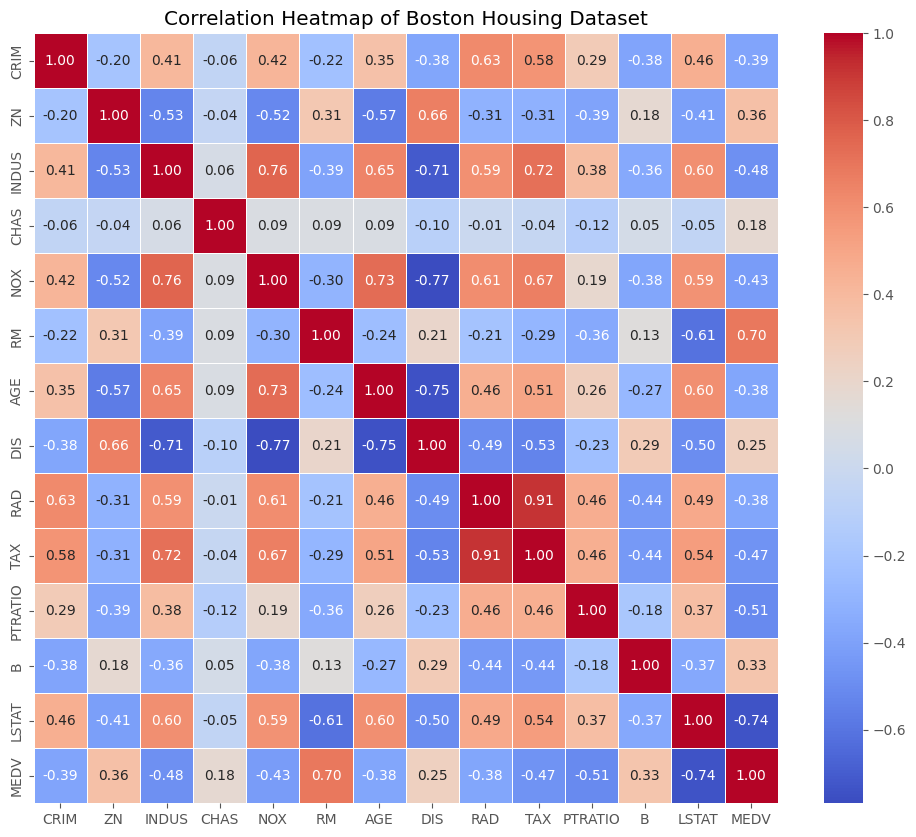

In [ ]:
# ==============================================================================
# CELL 9. CORRELATION HEATMAP
#
# This heatmap visualizes the relationships among all numerical variables.
# Darker colors indicate stronger positive or negative correlations.
# ==============================================================================

# Create the heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Boston Housing Dataset")

# Save the figure
plt.savefig(CHARTS_DIR / "Correlation_Heatmap.png",
            dpi=300,
            bbox_inches="tight")

# Display the heatmap
plt.show()

In [ ]:
# ==============================================================================
# CELL 10. FEATURE SELECTION
#
# Since this task requires a Simple Linear Regression model, only ONE predictor
# variable will be used.
#
# This cell automatically selects the feature with the strongest absolute
# correlation with the target variable (MEDV).
# ==============================================================================

# Calculate the correlation of every feature with MEDV
target_correlation = correlation_matrix["MEDV"].drop("MEDV")

# Sort correlations by absolute value
sorted_corr = target_correlation.abs().sort_values(ascending=False)

# Display correlations
display(sorted_corr)

# Select the best predictor
best_feature = sorted_corr.index[0]

print(f"The selected predictor variable is: {best_feature}")

# Store predictor and target names
FEATURE = best_feature
TARGET = "MEDV"

,MEDV
LSTAT,0.738187
RM,0.695365
PTRATIO,0.508411
INDUS,0.484126
TAX,0.468543
NOX,0.427295
CRIM,0.388249
RAD,0.381690
AGE,0.376932
ZN,0.360393


The selected predictor variable is: LSTAT


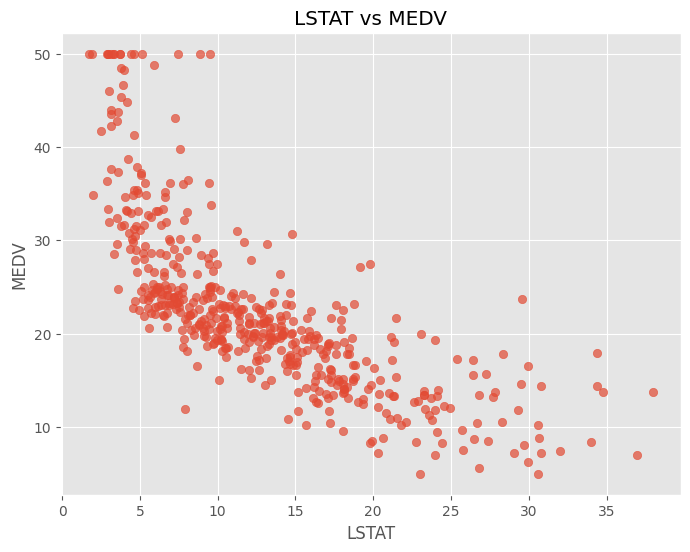

In [ ]:
# ==============================================================================
# CELL 11. SCATTER PLOT
#
# This scatter plot visualizes the relationship between the selected predictor
# variable and the target variable.
#
# A linear pattern suggests that Simple Linear Regression is appropriate.
# ==============================================================================

# Create scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    df[FEATURE],
    df[TARGET],
    alpha=0.7
)

# Label the axes
plt.xlabel(FEATURE)
plt.ylabel(TARGET)

# Add title
plt.title(f"{FEATURE} vs {TARGET}")

# Save figure
plt.savefig(
    CHARTS_DIR / "Scatter_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==============================================================================
# CELL 12. PREPARE FEATURES AND TARGET
#
# Machine learning models require:
#
# X = Predictor variable(s)
# y = Target variable
#
# Since this is Simple Linear Regression, X contains only one feature.
# ==============================================================================

# Store predictor variable
X = df[[FEATURE]]

# Store target variable
y = df[TARGET]

print("Predictor Variable:")
display(X.head())

print("\nTarget Variable:")
display(y.head())

Predictor Variable:


,LSTAT
0,9.14
1,4.03
2,2.94
3,5.33
4,5.21



Target Variable:


,MEDV
0,21.6
1,34.7
2,33.4
3,36.2
4,28.7


In [ ]:
# ==============================================================================
# CELL 13. SPLIT THE DATASET
#
# The dataset is divided into:
#
# 80% Training Data
# 20% Testing Data
#
# The model learns from the training data and is evaluated using unseen
# testing data.
# ==============================================================================

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 404
Testing Samples  : 101


In [ ]:
# ==============================================================================
# CELL 14. BUILD THE LINEAR REGRESSION MODEL
#
# This cell creates and trains a Simple Linear Regression model using
# the training dataset.
# ==============================================================================

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression Model Successfully Trained.")

Linear Regression Model Successfully Trained.


In [ ]:
# ==============================================================================
# CELL 15. MODEL COEFFICIENTS
#
# The intercept is the predicted value when the predictor is zero.
#
# The coefficient indicates how much the predicted house price changes
# for every one-unit increase in the selected feature.
# ==============================================================================

# Extract intercept
intercept = model.intercept_

# Extract coefficient
coefficient = model.coef_[0]

print(f"Intercept : {intercept:.4f}")
print(f"Coefficient ({FEATURE}) : {coefficient:.4f}")

# Save coefficients
coef_df = pd.DataFrame({
    "Feature":[FEATURE],
    "Coefficient":[coefficient],
    "Intercept":[intercept]
})

coef_df.to_csv(
    TABLES_DIR / "Model_Coefficients.csv",
    index=False
)

Intercept : 35.3473
Coefficient (LSTAT) : -0.9925


In [ ]:
# ==============================================================================
# CELL 16. MAKE PREDICTIONS
#
# The trained model predicts house prices using the testing dataset.
# ==============================================================================

# Predict house prices
y_pred = model.predict(X_test)

# Create comparison table
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

display(prediction_df.head())

# Save predictions
prediction_df.to_csv(
    TABLES_DIR / "Predictions.csv",
    index=False
)

print("Predictions saved successfully.")

,Actual,Predicted
173,22.6,25.779953
274,32.0,32.389765
490,13.6,17.413478
72,23.4,27.864128
305,33.4,28.926065


Predictions saved successfully.


In [ ]:
# ==============================================================================
# CELL 17. MODEL EVALUATION
#
# This cell evaluates the performance of the Simple Linear Regression model.
#
# Metrics Used:
#
# R² Score
# Mean Absolute Error (MAE)
# Mean Squared Error (MSE)
# Root Mean Squared Error (RMSE)
# ==============================================================================

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Display results
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"R² Score              : {r2:.4f}")
print(f"Mean Absolute Error   : {mae:.4f}")
print(f"Mean Squared Error    : {mse:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")

# Save metrics
metrics_df = pd.DataFrame({
    "Metric":["R² Score","MAE","MSE","RMSE"],
    "Value":[r2,mae,mse,rmse]
})

metrics_df.to_csv(
    TABLES_DIR / "Evaluation_Metrics.csv",
    index=False
)

MODEL PERFORMANCE
R² Score              : 0.4997
Mean Absolute Error   : 4.1365
Mean Squared Error    : 27.8763
Root Mean Squared Error : 5.2798


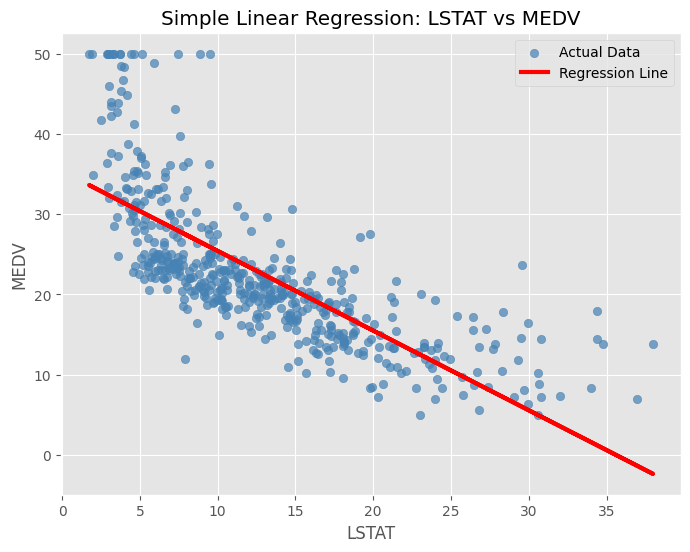

In [ ]:
# ==============================================================================
# CELL 18. REGRESSION LINE VISUALIZATION
#
# This cell visualizes the fitted Simple Linear Regression model.
#
# The blue dots represent the actual observations, while the red line
# represents the best-fit regression line learned by the model.
#
# A regression line that closely follows the data points indicates a
# stronger linear relationship between the predictor and the target.
# ==============================================================================

# Create a new figure
plt.figure(figsize=(8,6))

# Plot the actual data points
plt.scatter(
    X,
    y,
    alpha=0.7,
    color="steelblue",
    label="Actual Data"
)

# Generate predictions using the entire dataset
y_line = model.predict(X)

# Plot the regression line
plt.plot(
    X,
    y_line,
    color="red",
    linewidth=3,
    label="Regression Line"
)

# Label the axes
plt.xlabel(FEATURE)
plt.ylabel(TARGET)

# Add title
plt.title(f"Simple Linear Regression: {FEATURE} vs {TARGET}")

# Display legend
plt.legend()

# Save the figure
plt.savefig(
    CHARTS_DIR / "Regression_Line.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

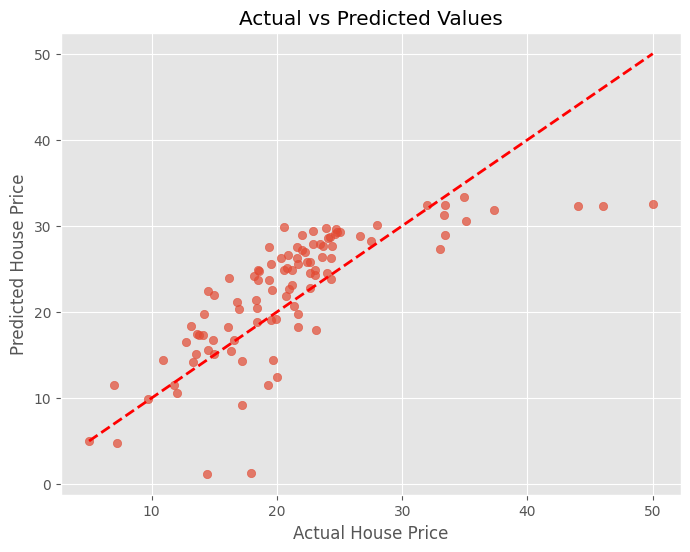

In [ ]:
# ==============================================================================
# CELL 19. ACTUAL VS PREDICTED VALUES
#
# This plot compares the actual house prices with the predicted house prices.
#
# If the model performs well, most points should lie close to the diagonal line.
# ==============================================================================

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Draw the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    linestyle="--"
)

# Label axes
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

# Add title
plt.title("Actual vs Predicted Values")

# Save figure
plt.savefig(
    CHARTS_DIR / "Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

# Display plot
plt.show()

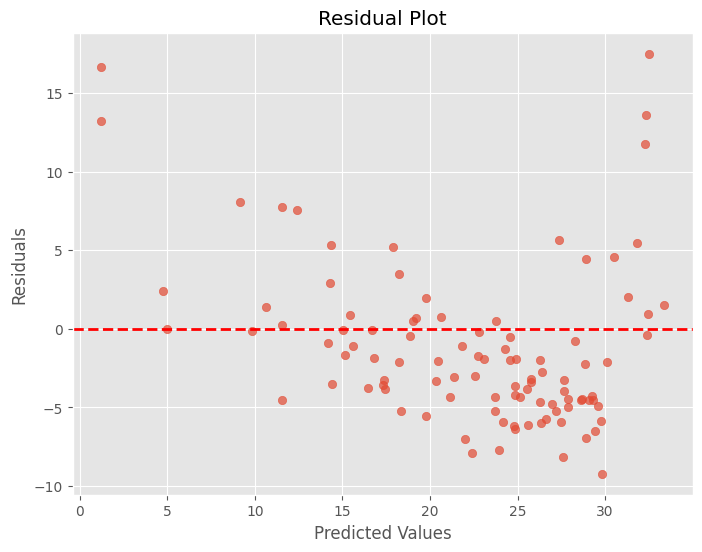

In [ ]:
# ==============================================================================
# CELL 20. RESIDUAL PLOT
#
# Residuals are the differences between the actual and predicted values.
#
# A good regression model should produce residuals that are randomly
# scattered around zero without any obvious pattern.
# ==============================================================================

# Calculate residuals
residuals = y_test - y_pred

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot of predicted values versus residuals
plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

# Draw horizontal reference line
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

# Label axes
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Add title
plt.title("Residual Plot")

# Save figure
plt.savefig(
    CHARTS_DIR / "Residual_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

# Display plot
plt.show()

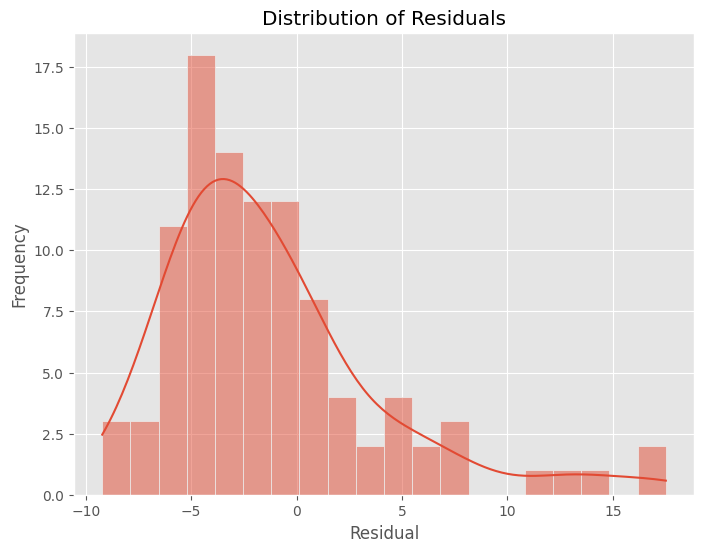

In [ ]:
# ==============================================================================
# CELL 21. DISTRIBUTION OF RESIDUALS
#
# This histogram shows how the residuals are distributed.
#
# Ideally, the residuals should resemble a normal distribution centered
# around zero, indicating that the model's prediction errors are random.
# ==============================================================================

# Create figure
plt.figure(figsize=(8,6))

# Plot histogram of residuals
sns.histplot(
    residuals,
    bins=20,
    kde=True
)

# Label axes
plt.xlabel("Residual")
plt.ylabel("Frequency")

# Add title
plt.title("Distribution of Residuals")

# Save figure
plt.savefig(
    CHARTS_DIR / "Residual_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display plot
plt.show()

In [ ]:
# ==============================================================================
# CELL 22. MODEL SUMMARY
#
# This cell provides a summary of the trained Simple Linear Regression model.
#
# It reports the selected predictor, regression equation, and performance
# metrics to help interpret the model's predictive ability.
# ==============================================================================

print("=" * 70)
print("SIMPLE LINEAR REGRESSION MODEL SUMMARY")
print("=" * 70)

print(f"\nTarget Variable     : {TARGET}")
print(f"Predictor Variable  : {FEATURE}")

print("\nRegression Equation:")
print(f"{TARGET} = {intercept:.4f} + ({coefficient:.4f} × {FEATURE})")

print("\nModel Performance Metrics")
print("-" * 40)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

print("\nInterpretation:")
print("-" * 40)

print(
    f"For every one-unit increase in {FEATURE}, "
    f"the predicted value of {TARGET} changes by "
    f"{coefficient:.4f} units."
)

print(
    "\nThe R² Score indicates the proportion of the variance "
    "in the target variable explained by the predictor variable."
)

print(
    "Lower MAE, MSE, and RMSE values indicate better prediction accuracy."
)

SIMPLE LINEAR REGRESSION MODEL SUMMARY

Target Variable     : MEDV
Predictor Variable  : LSTAT

Regression Equation:
MEDV = 35.3473 + (-0.9925 × LSTAT)

Model Performance Metrics
----------------------------------------
R² Score : 0.4997
MAE      : 4.1365
MSE      : 27.8763
RMSE     : 5.2798

Interpretation:
----------------------------------------
For every one-unit increase in LSTAT, the predicted value of MEDV changes by -0.9925 units.

The R² Score indicates the proportion of the variance in the target variable explained by the predictor variable.
Lower MAE, MSE, and RMSE values indicate better prediction accuracy.


In [ ]:
# ==============================================================================
# CELL 23. SAVE COMPLETE ANALYSIS REPORT
#
# This cell compiles the key outputs of the analysis into a single summary
# table and saves it to Google Drive.
# ==============================================================================

# Create summary table
summary_df = pd.DataFrame({
    "Item": [
        "Dataset Rows",
        "Dataset Columns",
        "Predictor Variable",
        "Target Variable",
        "Intercept",
        "Coefficient",
        "R² Score",
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        FEATURE,
        TARGET,
        intercept,
        coefficient,
        r2,
        mae,
        mse,
        rmse
    ]
})

# Display summary
display(summary_df)

# Save summary table
summary_df.to_csv(
    TABLES_DIR / "Analysis_Summary.csv",
    index=False
)

print("\nAnalysis summary saved successfully.")
print(f"\nAll outputs have been saved to:\n{OUTPUT_DIR}")

,Item,Value
0,Dataset Rows,505
1,Dataset Columns,14
2,Predictor Variable,LSTAT
3,Target Variable,MEDV
4,Intercept,35.347309
5,Coefficient,-0.992464
6,R² Score,0.499727
7,Mean Absolute Error,4.136508
8,Mean Squared Error,27.876273
9,Root Mean Squared Error,5.279799



Analysis summary saved successfully.

All outputs have been saved to:
/content/drive/MyDrive/LinearRegressionLab/LinearRegression_Output
